# CheXNet -> MURA Domain Transfer
## Phase 1 - Environment & Workspace Calibration

Run these cells top-to-bottom at the start of **every** Colab session.
The T4 VM is wiped on disconnect, so Cell 2 re-fetches the repo each time.

Before running: **Runtime -> Change runtime type -> T4 GPU**.

In [17]:
# Cell 1 - Confirm the runtime has the T4 GPU
!nvidia-smi --query-gpu=name,memory.total --format=csv

name, memory.total [MiB]
Tesla T4, 15360 MiB


In [18]:
# Cell 2 - Bootstrap: pull the whole project onto the Colab VM
# Identical for both collaborators. No Google Drive needed - git carries
# the code, the 81 MB weights, and the MURA data.
import os

REPO_URL = "https://github.com/sofiaorlov9821/CheXNet.git"
CHEXNET  = "/content/CheXNet"

if not os.path.exists(CHEXNET):
    !git clone {REPO_URL} {CHEXNET}      # first run of the session
else:
    !cd {CHEXNET} && git pull            # already cloned -> just update

assert os.path.exists(f"{CHEXNET}/model.pth.tar"), "clone failed - check repo access"
print("[OK] Project ready at", CHEXNET)
print(os.listdir(CHEXNET))

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 1), reused 3 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 158.56 KiB | 807.00 KiB/s, done.
From https://github.com/sofiaorlov9821/CheXNet
   82d178d..820bfa7  master     -> origin/master
Updating 82d178d..820bfa7
Fast-forward
 final_p.ipynb | 348 +++++++++++++++++++++++++++++++++++++++++++++++++++++-----
 1 file changed, 318 insertions(+), 30 deletions(-)
[OK] Project ready at /content/CheXNet
['.gitattributes', 'model.py', 'ChestX-ray14', '.git', 'final_p.ipynb', 'read_data.py', '.gitignore', 'localization', 'MURA_MSK_Xrays_files', 'model.pth.tar', 'README.md']


In [19]:
# Cell 3 - Inspect the CheXNet checkpoint (model.pth.tar)
import torch

ckpt = torch.load(f"{CHEXNET}/model.pth.tar", map_location="cpu")

# A checkpoint is a dict: the weights ('state_dict') plus training bookkeeping.
print("Top-level keys:", list(ckpt.keys()))
print("epoch:", ckpt.get("epoch"), "| best_loss:", ckpt.get("best_loss"))

sd = ckpt["state_dict"]
print("\nNumber of weight tensors:", len(sd))

print("\nFirst 8 layers (name + shape):")
for k, v in list(sd.items())[:8]:
    print(f"  {k:55s} {tuple(v.shape)}")

print("\nOriginal 14-class classifier head:")
for k, v in sd.items():
    if "classifier" in k:
        print(f"  {k:55s} {tuple(v.shape)}")

Top-level keys: ['optimizer', 'epoch', 'arch', 'state_dict']
epoch: 14 | best_loss: None

Number of weight tensors: 606

First 8 layers (name + shape):
  module.densenet121.features.conv0.weight                (64, 3, 7, 7)
  module.densenet121.features.norm0.weight                (64,)
  module.densenet121.features.norm0.bias                  (64,)
  module.densenet121.features.norm0.running_mean          (64,)
  module.densenet121.features.norm0.running_var           (64,)
  module.densenet121.features.denseblock1.denselayer1.norm.1.weight (64,)
  module.densenet121.features.denseblock1.denselayer1.norm.1.bias (64,)
  module.densenet121.features.denseblock1.denselayer1.norm.1.running_mean (64,)

Original 14-class classifier head:
  module.densenet121.classifier.0.weight                  (14, 1024)
  module.densenet121.classifier.0.bias                    (14,)


In [20]:
# Cell 4 - Make CheXNet importable and load the model class
import sys
if CHEXNET not in sys.path:
    sys.path.append(CHEXNET)             # append = won't shadow torch

from model import DenseNet121            # gets the class; does NOT run main()
MURA_DIR = f"{CHEXNET}/MURA_MSK_Xrays_files"
assert os.path.isdir(MURA_DIR), "MURA folder not found"
print("[OK] Imported DenseNet121")
print("[OK] MURA data at", MURA_DIR)

[OK] Imported DenseNet121
[OK] MURA data at /content/CheXNet/MURA_MSK_Xrays_files


In [21]:
# Cell 5 - Confirm the GPU is live (final Phase 1 check)
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")
assert DEVICE.type == "cuda", "No GPU - Runtime > Change runtime type > T4 GPU"

Device: cuda
GPU: Tesla T4


---
## Phase 2 - Preprocessing & MURA Subset Loading

Body part: **XR_FOREARM** (the subset in this repo).  
Labels come from the study-folder name: `..._positive` -> **1 (abnormal)**, `..._negative` -> **0 (normal)**.

Pipeline: `SquarePad` (no distortion) -> `Resize(224)` -> spatial augmentations (train only) -> ImageNet normalization.

In [22]:
# Cell 6 - Imports + SquarePad + transforms
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class SquarePad:
    """Pad a PIL image to a square (side = longer edge) BEFORE resizing.

    Resizing a non-square X-ray straight to 224x224 stretches the anatomy.
    Padding to a square first preserves the aspect ratio so bones keep their
    true proportions. Padding is symmetric and filled with 0 (black), which
    matches the typical dark radiograph background.
    """
    def __call__(self, image):
        w, h = image.size
        s = max(w, h)
        left = (s - w) // 2
        top  = (s - h) // 2
        right = s - w - left
        bottom = s - h - top
        return TF.pad(image, (left, top, right, bottom), fill=0)


# Train: augment for spatial invariance. Eval: deterministic, no augmentation.
train_tf = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print('[OK] SquarePad + transforms defined')

[OK] SquarePad + transforms defined


In [23]:
# Cell 7 - MURA Dataset
class MURADataset(Dataset):
    """MURA musculoskeletal radiographs as a binary image classifier dataset.

    Directory layout:
        <root>/<split>/<body_part>/patientXXXXX/studyN_positive|negative/imageN.png

    The label is parsed from the study-folder name ('positive' -> 1 abnormal,
    'negative' -> 0 normal). Each PNG is treated as one independent sample
    (per-image classification), which is standard for a proof-of-concept.

    Args:
        root:      path to MURA_MSK_Xrays_files
        body_part: e.g. 'XR_FOREARM'
        split:     'train' or 'valid'
        transform: torchvision transform applied to each PIL image
    """
    def __init__(self, root, body_part='XR_FOREARM', split='train', transform=None):
        self.transform = transform
        self.samples = []  # (image_path, label)
        base = os.path.join(root, split, body_part)
        for patient in sorted(os.listdir(base)):
            pdir = os.path.join(base, patient)
            if not os.path.isdir(pdir):
                continue
            for study in sorted(os.listdir(pdir)):
                sdir = os.path.join(pdir, study)
                if not os.path.isdir(sdir):
                    continue
                label = 1 if 'positive' in study.lower() else 0
                for fname in sorted(os.listdir(sdir)):
                    if fname.lower().endswith('.png'):   # skip .DS_Store etc.
                        self.samples.append((os.path.join(sdir, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')   # 1-ch X-ray -> 3-ch for DenseNet
        if self.transform is not None:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)
print('[OK] MURADataset defined')

[OK] MURADataset defined


In [24]:
# Cell 8 - Build datasets, dataloaders, and report class balance
BATCH_SIZE = 32   # comfortable on a T4 at 224x224
BODY_PART  = 'XR_FOREARM'

train_ds = MURADataset(MURA_DIR, BODY_PART, 'train', train_tf)
valid_ds = MURADataset(MURA_DIR, BODY_PART, 'valid', eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# Class balance (MURA is imbalanced - we'll use this for pos_weight later)
def counts(ds):
    pos = sum(l for _, l in ds.samples)
    return len(ds), int(pos), len(ds) - int(pos)

n_tr, pos_tr, neg_tr = counts(train_ds)
n_va, pos_va, neg_va = counts(valid_ds)
print(f'TRAIN: {n_tr} imgs | abnormal {pos_tr} / normal {neg_tr}')
print(f'VALID: {n_va} imgs | abnormal {pos_va} / normal {neg_va}')
pos_weight = torch.tensor([neg_tr / max(pos_tr, 1)])   # save for Phase 3 loss
print(f'pos_weight (neg/pos) = {pos_weight.item():.3f}')

TRAIN: 1825 imgs | abnormal 661 / normal 1164
VALID: 301 imgs | abnormal 151 / normal 150
pos_weight (neg/pos) = 1.761


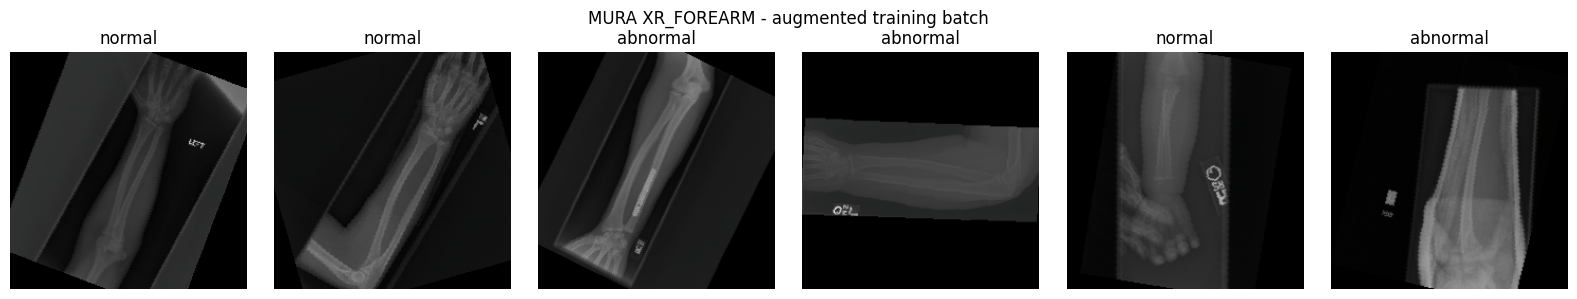

Batch tensor: torch.Size([32, 3, 224, 224])


In [25]:
# Cell 9 - Sanity check: visualise one augmented batch
import matplotlib.pyplot as plt
import numpy as np

mean = np.array(IMAGENET_MEAN); std = np.array(IMAGENET_STD)
imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 6, figsize=(16, 3))
for i, ax in enumerate(axes):
    img = imgs[i].permute(1, 2, 0).numpy() * std + mean   # un-normalize
    ax.imshow(np.clip(img, 0, 1))
    ax.set_title('abnormal' if labels[i] == 1 else 'normal')
    ax.axis('off')
plt.suptitle('MURA XR_FOREARM - augmented training batch')
plt.tight_layout(); plt.show()
print('Batch tensor:', imgs.shape)   # expect [32, 3, 224, 224]

---
## Phase 3 - Experiment 1: Frozen CheXNet Backbone

Load CheXNet's pretrained DenseNet-121, **freeze the whole backbone**, and train **only a new 1-node classifier** on MURA.
This measures how useful CheXNet's chest-xray features are *as-is* for bone abnormality detection.

Metrics on the validation set: **AUC-ROC, F1, Precision, Recall**.

In [ ]:
# Cell 10 - Robust CheXNet weight loader
import re
import torch
import torch.nn as nn

CKPT_PATH = f"{CHEXNET}/model.pth.tar"

def load_chexnet_backbone(ckpt_path, device):
    """Load arnoweng CheXNet weights into a DenseNet121(14) model.

    Fixes the three quirks of the released checkpoint (all confirmed for this file):
      1. Weights live under checkpoint['state_dict'].
      2. Keys carry a 'module.' prefix (saved wrapped in DataParallel).
      3. Keys use OLD torchvision DenseNet naming ('norm.1' -> 'norm1').
    Returns the model with its original 14-class head still matching the ckpt.
    """
    model = DenseNet121(14)                        # same head as when ckpt was saved
    checkpoint = torch.load(ckpt_path, map_location='cpu')   # safe single-GPU load
    state_dict = checkpoint['state_dict']

    # old-torchvision denselayer fix: '...norm.1.weight' -> '...norm1.weight'
    pattern = re.compile(
        r'^(.*denselayer\d+\.(?:norm|relu|conv))\.'
        r'((?:[12])\.(?:weight|bias|running_mean|running_var))$')

    fixed = {}
    for key, val in state_dict.items():
        k = key[len('module.'):] if key.startswith('module.') else key
        m = pattern.match(k)
        if m:
            k = m.group(1) + m.group(2)            # merge 'norm.1' -> 'norm1'
        fixed[k] = val

    missing, unexpected = model.load_state_dict(fixed, strict=False)
    print(f'[OK] CheXNet weights loaded | missing={len(missing)} unexpected={len(unexpected)}')
    return model.to(device)

In [ ]:
# Cell 11 - Build the FROZEN model (Experiment 1)
def build_frozen_model(ckpt_path, device):
    """CheXNet backbone frozen; only a fresh 1-logit classifier is trainable."""
    model = load_chexnet_backbone(ckpt_path, device)

    for p in model.parameters():          # freeze EVERYTHING
        p.requires_grad = False

    # Replace the 14-way Sigmoid head with a single logit (no Sigmoid:
    # BCEWithLogitsLoss applies it internally). New layer is trainable by default.
    num_ftrs = model.densenet121.classifier[0].in_features
    model.densenet121.classifier = nn.Linear(num_ftrs, 1).to(device)

    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f'Trainable params: {n_train:,} / {n_total:,}  (only the classifier head)')
    return model

In [ ]:
# Cell 12 - Loss, training loop, and evaluation (reused by all 3 experiments)
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))  # pos_weight from Phase 2

def train_one_epoch(model, loader, optimizer, device):
    """One pass over the training data. Returns mean loss."""
    model.train()
    running = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)          # [B]
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running += loss.item() * imgs.size(0)
    return running / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device):
    """Validation metrics at threshold 0.5: AUC, F1, Precision, Recall."""
    model.eval()
    probs_all, labels_all = [], []
    for imgs, labels in loader:
        logits = model(imgs.to(device)).squeeze(1)
        probs_all.append(torch.sigmoid(logits).cpu())
        labels_all.append(labels)
    probs = torch.cat(probs_all).numpy()
    labels = torch.cat(labels_all).numpy()
    preds = (probs >= 0.5).astype(int)
    return {'AUC': roc_auc_score(labels, probs),
            'F1': f1_score(labels, preds, zero_division=0),
            'Precision': precision_score(labels, preds, zero_division=0),
            'Recall': recall_score(labels, preds, zero_division=0)}

In [ ]:
# Cell 13 - Train Experiment 1 (Frozen CheXNet)
torch.manual_seed(42)

exp1_model = build_frozen_model(CKPT_PATH, DEVICE)

# Adam over ONLY the trainable (classifier) params. Higher LR is fine - it's just a linear head.
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, exp1_model.parameters()), lr=1e-3)

EPOCHS = 10
for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(exp1_model, train_loader, optimizer, DEVICE)
    m = evaluate(exp1_model, valid_loader, DEVICE)
    print(f"Epoch {epoch:02d} | loss {loss:.4f} | "
          f"AUC {m['AUC']:.3f}  F1 {m['F1']:.3f}  P {m['Precision']:.3f}  R {m['Recall']:.3f}")

exp1_metrics = evaluate(exp1_model, valid_loader, DEVICE)
print('\n[Experiment 1 - Frozen CheXNet] final:', {k: round(v,3) for k,v in exp1_metrics.items()})
torch.cuda.empty_cache()

In [ ]:
# Cell 14 - Preview the model architecture
# Run AFTER Cell 13 (needs exp1_model). Shows the swapped head + frozen/trainable split.
try:
    from torchinfo import summary
except ImportError:
    !pip install torchinfo -q
    from torchinfo import summary

model = exp1_model  # the frozen-backbone Experiment-1 model

# 1) The classifier head we swapped in (14-way Sigmoid -> single logit)
print('Classifier head:', model.densenet121.classifier)

# 2) Frozen vs trainable parameter split
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f'Trainable: {n_train:,}  |  Frozen: {n_total - n_train:,}  |  Total: {n_total:,}')

# 3) Layer-by-layer summary (input = 1 image, 3x224x224). 'Param #' column
#    shows sizes; the Trainable column shows what the freeze actually did.
summary(model, input_size=(1, 3, 224, 224),
        col_names=('output_size', 'num_params', 'trainable'),
        depth=2)